# Experiment Plotter

In [2]:
import pandas as pd
import numpy as np
from scipy import constants

## Unpack Data

In [57]:
df = pd.read_csv('/Users/omalleysherlock/Developer/OFDM-Sense/experiments/mfdelay_09_03_26.csv')

delay0 = df['delay0']
distance0 = df['distance0']

delay1 = df['delay1']
distance1 = df['distance1']

delay2 = df['delay2']
distance2 = df['distance2']

evm0 = df['evm0']
evm1 = df['evm1']
evm2 = df['evm2']


ser0 = df['ser0']
ser1 = df['ser1']
ser2 = df['ser2']

ber0 = df['ber0']
ber1 = df['ber1']
ber2 = df['ber2']


actual_distance = np.linspace(110, 50, len(delay0))

Q1 = df['delay2'].quantile(0.25)
Q3 = df['delay2'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the entire dataframe to keep rows where delay0 is within bounds
df_cleaned = df[(df['delay2'] >= lower_bound) & (df['delay2'] <= upper_bound)].copy()

# Re-assign your variables from the cleaned dataframe
delay2_clean = df_cleaned['delay2']
distance2_clean = df_cleaned['distance2']
# ... and so on

# Calculate Angle

In [4]:
d = 0.1 #Distance between RX modules
C = constants.c
for i in range(len(delay0)):
    delta_t = (delay0[i] * 1e-9) - (delay1[i] * 1e-9)
    val = (delta_t * C) / d
    print(val)
    theta = np.arcsin((delta_t * C)/ d)
    print(theta)


15.289415358013208
nan
13.490660610009266
nan
16.788377647955553
nan
14.689830442011894
nan
9.293566198040692
nan
12.89107569400795
nan
14.989622899992238
nan
15.28941535797258
nan
10.49273603000269
nan
13.79045306798961
nan
8.394188824018405
nan
11.092320946004008
nan
14.09024552601058
nan
7.494811449996119
nan
10.792528488023665
nan
12.89107569400795
nan
11.392113404024979
nan
14.390037984031553
nan
15.889000273933267
nan
12.291490778006636
nan
11.991698319985664
nan
14.689830441971266
nan
9.593358656021035
nan
14.989622899992238
nan
10.792528488023665
nan
10.19294357198172
nan
13.490660609968636
nan
13.79045306798961
nan
10.792528487983034
nan
13.490660609968636
nan
14.989622899992238
nan
13.190868152028923
nan
14.689830442011894
nan
15.28941535797258
nan
10.19294357202235
nan
12.291490777966008
nan
14.689830441971266
nan
9.293566197959434
nan
10.49273603000269
nan
12.291490777966008
nan
11.392113403984348
nan
12.89107569400795
nan
12.291490778006636
nan
12.591283236027607
nan
11.69

/var/folders/p7/p_9cgcc968xcbtfbxm8sv95m0000gn/T/ipykernel_56831/1752691345.py:7: RuntimeWarning: invalid value encountered in arcsin
  theta = np.arcsin((delta_t * C)/ d)


## Plot Data 

In [5]:
import matplotlib.pyplot as plt

In [ ]:
delay2_top = delay2_clean[delay2_clean > -9.8e4]
delay2_bot = delay2_clean[delay2_clean <= -9.8e4]

0    -97995.8
2    -97995.8
4    -97995.4
5    -97995.5
6    -97995.9
9    -97995.6
12   -97995.8
14   -97995.9
15   -97996.1
16   -97996.1
21   -97996.2
22   -97996.0
23   -97996.1
24   -97996.0
26   -97996.2
28   -97996.3
29   -97996.3
30   -97996.2
32   -97996.3
33   -97996.5
34   -97996.3
39   -97996.6
41   -97997.2
44   -97996.5
45   -97996.6
46   -97996.6
49   -97997.0
55   -97997.1
56   -97996.8
57   -97997.1
58   -97997.2
Name: delay2, dtype: float64


In [36]:
delay_diff = delay2_top.reset_index(drop=True) - delay2_bot.reset_index(drop=True)
avg_diff = delay_diff.mean()
print(avg_diff)


5.149999999998337


In [40]:
delay2_clean.head()

0   -97995.8
1   -98000.4
2   -97995.8
3   -98000.6
4   -97995.4
Name: delay2, dtype: float64

Slope:0.03527322404382973


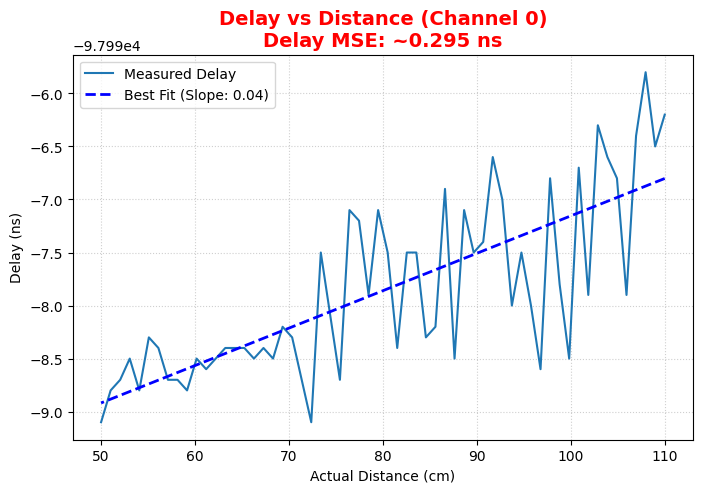

In [62]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

delay = delay0
#delay.loc[delay2_clean < -9.8e4] -= avg_diff




actual_distance = np.linspace(110,50,len(delay))

# 1. Calculate Line of Best Fit
# This creates the "Predicted" values (line_of_best_fit)
m, b = np.polyfit(actual_distance, delay, 1)
line_of_best_fit = m * actual_distance + b

print(f"Slope:{(m)}")

# 2. Calculate MSE 
mse = mean_squared_error(delay, line_of_best_fit)

# 3. Plotting
plt.figure(figsize=(8, 5))

# Original Data
plt.plot(actual_distance, delay, label='Measured Delay')

# Line of Best Fit
plt.plot(actual_distance, line_of_best_fit, color='blue', linestyle='--', 
         linewidth=2, label=f'Best Fit (Slope: {m:.2f})')

plt.title(f"Delay vs Distance (Channel 0)\nDelay MSE: ~{mse:.3f} ns", fontsize=14, color='red', fontweight='bold')
plt.xlabel("Actual Distance (cm)")
plt.ylabel("Delay (ns)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

# Plot Calced Distance Data

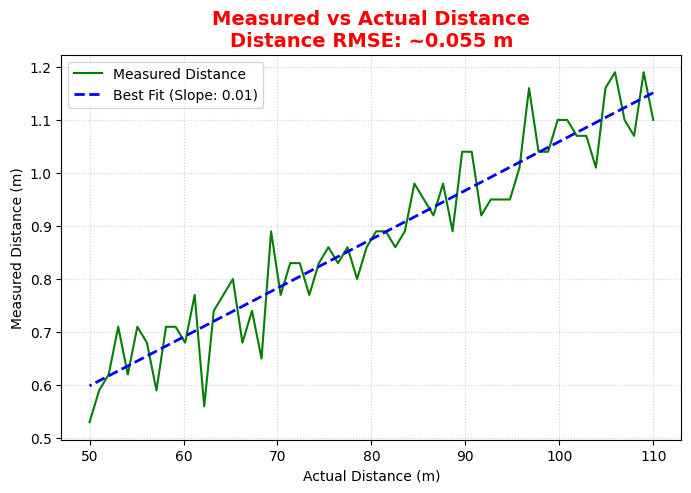

In [17]:
# Calculate Line of Best Fit
m, b = np.polyfit(actual_distance, distance1, 1)
line_of_best_fit = m * actual_distance + b

# Calculate MSE and then RMSE
mse = mean_squared_error(distance1, line_of_best_fit)
rmse = np.sqrt(mse)  # Convert to meters

# Plotting
plt.figure(figsize=(8, 5))

# Original Data
plt.plot(actual_distance, distance1, color='green', label='Measured Distance')

# Line of Best Fit
plt.plot(actual_distance, line_of_best_fit, color='blue', linestyle='--', 
         linewidth=2, label=f'Best Fit (Slope: {m:.2f})')

# UPDATED: Title says "Distance" and uses RMSE for "m" units
plt.title(f"Measured vs Actual Distance\nDistance RMSE: ~{rmse:.3f} m", fontsize=14, color='red', fontweight='bold')

plt.xlabel("Actual Distance (m)")
plt.ylabel("Measured Distance (m)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

# PLOT METRICS

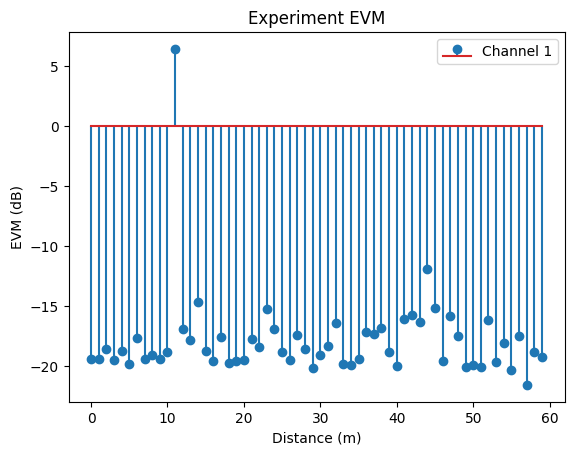

Average Channel 1 EVM:-17.60706800473108, Average Channel 1 -17.72373541993492


In [65]:

plt.figure()

#plt.stem(evm0, label = "Channel 0")
plt.stem(evm2, label = "Channel 1")
plt.legend()
plt.title("Experiment EVM")
plt.xlabel("Distance (m)")
plt.ylabel("EVM (dB)")
plt.show()

average_evm0 = np.average(evm0)
average_evm1 = np.average(evm1)

print(f"Average Channel 1 EVM:{average_evm0}, Average Channel 1 {average_evm1}")
 

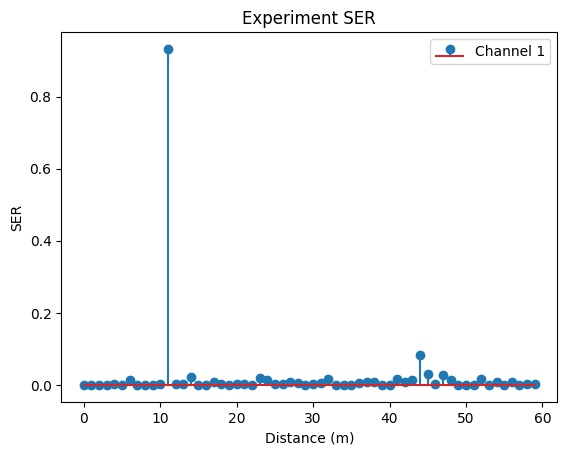

Average Channel 1 EVM:0.009229229229229221, Average Channel 1 0.009229229229229221


In [67]:

plt.figure()

#plt.stem(ser0, label = "Channel 0")
plt.stem(ser2, label = "Channel 1")
plt.legend()
plt.title("Experiment SER")
plt.xlabel("Distance (m)")
plt.ylabel("SER")
plt.show()

average_ser0 = np.average(ser0)
average_ser1 = np.average(ser1)

print(f"Average Channel 1 EVM:{average_ser1}, Average Channel 1 {average_ser1}")

# 

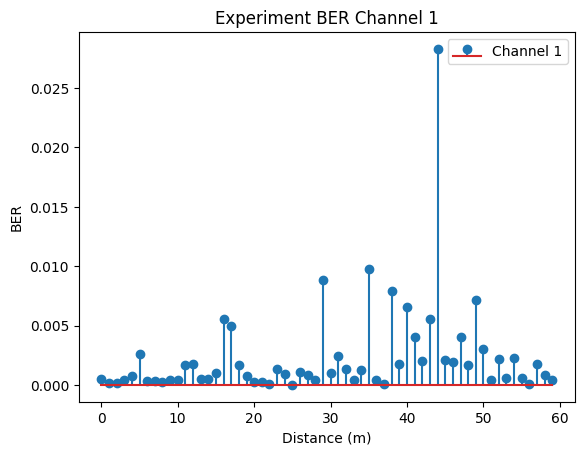

Average Channel ` EVM:0.002337337337337299, Average Channel 1 0.002337337337337299


In [11]:
plt.figure()

#plt.stem(ber0, label = "Channel 0")
plt.stem(ber1, label = "Channel 1")
plt.legend()
plt.title("Experiment BER Channel 1")
plt.xlabel("Distance (m)")
plt.ylabel("BER")
plt.show()

average_ber0 = np.average(ber0)
average_ber1 = np.average(ber1)

print(f"Average Channel ` EVM:{average_ber1}, Average Channel 1 {average_ber1}")